In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines import CoxPHFitter

In [2]:
product = pd.read_csv("product_test.csv")
portfolio = pd.read_csv("portfolio_test.csv")

In [3]:
product


,PRODUCT_ID,TOTAL_VALUE,DELIVERY_DATE
0,1080038,468.438528,2023-11-13T06:32:50.000Z
1,1168653,792.127033,2024-02-28T18:02:22.000Z
2,1083616,925.333331,2024-04-30T20:14:56.000Z
3,1283400,2388.989747,2024-12-23T17:54:02.000Z
4,683050,2534.828414,2022-01-13T12:22:48.000Z
...,...,...,...
885,991957,1098.067087,2023-08-17T08:59:41.000Z
886,1196275,2517.768861,2024-04-17T20:40:58.000Z
887,1176495,863.932143,2024-03-11T15:24:14.000Z
888,915929,2288.836022,2023-03-01T13:13:47.000Z


In [4]:
portfolio

,PRODUCT_ID,PORTFOLIO_DATE,DAYS_OVER_DUE
0,919293,2025-11-25,0.0
1,1274263,2025-11-25,1.0
2,1216388,2025-11-25,0.0
3,805540,2025-11-25,0.0
4,915996,2025-11-25,0.0
...,...,...,...
23705,725276,2022-04-26,1.0
23706,696473,2022-03-25,1.0
23707,681077,2022-03-25,0.0
23708,710031,2022-03-25,2.0


In [5]:
print(product.head())
print(portfolio.head())

print(product.info())
print(portfolio.info())

   PRODUCT_ID  TOTAL_VALUE             DELIVERY_DATE
0     1080038   468.438528  2023-11-13T06:32:50.000Z
1     1168653   792.127033  2024-02-28T18:02:22.000Z
2     1083616   925.333331  2024-04-30T20:14:56.000Z
3     1283400  2388.989747  2024-12-23T17:54:02.000Z
4      683050  2534.828414  2022-01-13T12:22:48.000Z
   PRODUCT_ID PORTFOLIO_DATE  DAYS_OVER_DUE
0      919293     2025-11-25            0.0
1     1274263     2025-11-25            1.0
2     1216388     2025-11-25            0.0
3      805540     2025-11-25            0.0
4      915996     2025-11-25            0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRODUCT_ID     890 non-null    int64  
 1   TOTAL_VALUE    890 non-null    float64
 2   DELIVERY_DATE  890 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 21.0+ KB
None
<class 'pandas.core.frame.

In [6]:
product

,PRODUCT_ID,TOTAL_VALUE,DELIVERY_DATE
0,1080038,468.438528,2023-11-13T06:32:50.000Z
1,1168653,792.127033,2024-02-28T18:02:22.000Z
2,1083616,925.333331,2024-04-30T20:14:56.000Z
3,1283400,2388.989747,2024-12-23T17:54:02.000Z
4,683050,2534.828414,2022-01-13T12:22:48.000Z
...,...,...,...
885,991957,1098.067087,2023-08-17T08:59:41.000Z
886,1196275,2517.768861,2024-04-17T20:40:58.000Z
887,1176495,863.932143,2024-03-11T15:24:14.000Z
888,915929,2288.836022,2023-03-01T13:13:47.000Z


In [7]:
#conversión de fechas 
product["DELIVERY_DATE"] = pd.to_datetime(product["DELIVERY_DATE"])
portfolio["PORTFOLIO_DATE"] = pd.to_datetime(portfolio["PORTFOLIO_DATE"])

In [8]:
product

,PRODUCT_ID,TOTAL_VALUE,DELIVERY_DATE
0,1080038,468.438528,2023-11-13 06:32:50+00:00
1,1168653,792.127033,2024-02-28 18:02:22+00:00
2,1083616,925.333331,2024-04-30 20:14:56+00:00
3,1283400,2388.989747,2024-12-23 17:54:02+00:00
4,683050,2534.828414,2022-01-13 12:22:48+00:00
...,...,...,...
885,991957,1098.067087,2023-08-17 08:59:41+00:00
886,1196275,2517.768861,2024-04-17 20:40:58+00:00
887,1176495,863.932143,2024-03-11 15:24:14+00:00
888,915929,2288.836022,2023-03-01 13:13:47+00:00


In [9]:
#se ordenan los valores
portfolio = portfolio.sort_values(["PRODUCT_ID", "PORTFOLIO_DATE"])
portfolio

,PRODUCT_ID,PORTFOLIO_DATE,DAYS_OVER_DUE
20091,483590,2022-01-26,1.0
5203,483590,2022-02-25,1.0
20077,483590,2022-03-25,1.0
15466,483590,2022-04-26,0.0
12905,483590,2022-05-26,1.0
...,...,...,...
2927,1285337,2025-06-25,4.0
13325,1285337,2025-07-25,2.0
15684,1285337,2025-08-25,3.0
18742,1285337,2025-09-24,2.0


In [10]:
records = []

In [11]:
for credit_id, group in portfolio.groupby('PRODUCT_ID'): #separa los creditos para que se trabajen uno por uno
    group = group.sort_values('PORTFOLIO_DATE')
    disb_date = product.loc[
        product['PRODUCT_ID'] == credit_id, 'DELIVERY_DATE' #busca la fecha en que se desembolosó el crédito
    ].values

    if len(disb_date) == 0:
        continue  

    disb_date = disb_date[0]
    group['time']= (group['PORTFOLIO_DATE'] - disb_date).dt.days #se calcula el dia en que "nació" el credito
    default = group[group['DAYS_OVER_DUE'] > 60] # se crea la funcióin para calcular si cae en default o no 

    if len(default) > 0:
        event_time = default.iloc[0]['time'] 
        event = 1
    else:
        event_time = group['time'].max()
        event = 0

    records.append({
        'PRODUCT_ID': credit_id,
        'time': event_time,
        'event': event
    })

In [12]:
# se crea el dataframe
survival_df = pd.DataFrame(records)
survival_df

,PRODUCT_ID,time,event
0,483590,922,0
1,483933,703,0
2,495772,615,0
3,501115,1250,0
4,519155,929,1
...,...,...,...
885,1285173,176,1
886,1285196,237,1
887,1285269,329,0
888,1285288,328,0


In [13]:
survival_df = survival_df.merge(product, on='PRODUCT_ID', how='left')
survival_df

,PRODUCT_ID,time,event,TOTAL_VALUE,DELIVERY_DATE
0,483590,922,0,2239.564190,2023-05-17 10:43:58+00:00
1,483933,703,0,727.609500,2023-12-22 12:37:37+00:00
2,495772,615,0,466.573210,2024-03-19 13:06:09+00:00
3,501115,1250,0,1538.930237,2022-06-23 16:27:08+00:00
4,519155,929,1,2123.307192,2022-05-10 14:59:32+00:00
...,...,...,...,...,...
885,1285173,176,1,1556.070675,2024-12-30 18:04:20+00:00
886,1285196,237,1,1524.830723,2024-12-30 18:15:04+00:00
887,1285269,329,0,2482.852780,2024-12-30 20:16:59+00:00
888,1285288,328,0,2389.680823,2024-12-31 09:45:57+00:00


In [14]:
#cuantos defaluts y censurados
print(survival_df.head())
print(survival_df['event'].value_counts())

   PRODUCT_ID  time  event  TOTAL_VALUE             DELIVERY_DATE
0      483590   922      0  2239.564190 2023-05-17 10:43:58+00:00
1      483933   703      0   727.609500 2023-12-22 12:37:37+00:00
2      495772   615      0   466.573210 2024-03-19 13:06:09+00:00
3      501115  1250      0  1538.930237 2022-06-23 16:27:08+00:00
4      519155   929      1  2123.307192 2022-05-10 14:59:32+00:00
event
0    678
1    212
Name: count, dtype: int64


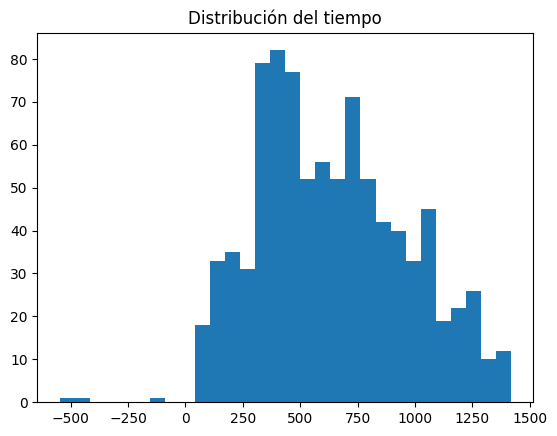

In [15]:
#gráfica sencilla para representar el tiempo 
plt.hist(survival_df['time'], bins=30)
plt.title('Distribución del tiempo')
plt.show()

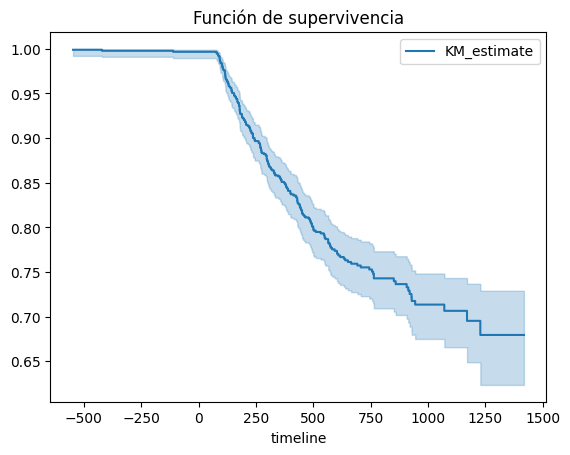

In [16]:
#modelo
kmf = KaplanMeierFitter()
kmf.fit(
    durations=survival_df['time'],
    event_observed=survival_df['event']
)
kmf.plot_survival_function()
plt.title('Función de supervivencia')
plt.show()

In [17]:
# se aplica cox para ver que factores aumentan o disminuyen el riesgo
model_df = survival_df[['time', 'event', 'TOTAL_VALUE']].dropna()

cph = CoxPHFitter()
cph.fit(model_df, duration_col='time', event_col='event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 890 total observations, 678 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 890
number of events observed = 212
   partial log-likelihood = -1369.73
         time fit was run = 2026-04-24 02:43:05 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
TOTAL_VALUE  0.00      1.00      0.00            0.00            0.00                1.00                1.00

             cmp to    z    p  -log2(p)
covariate                              
TOTAL_VALUE    0.00 2.20 0.03      5.16
---
Concordance = 0.55
Partial AIC = 2741.45
log-likelihood ratio test = 4.90 on 1 df
-log2(p) of ll-ratio test = 5.22